# Nuclear Waste Canister Temperature Prediction
**CIVIL-226 - Introduction to Machine Learning for Engineers**   
**Members:** NAJA Nour | CLERICI Alessandro


**SCIPERS:** 381 792 |

## Objectif
Prédire la température autour de conteneurs de déchets nucléaires à des positions de capteurs non observés, en utilisant la puissance de chauffage, le temps, et les coordonnées spatiales 3D des capteurs.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

print('Imports OK')

Imports OK


## 2. Chargement des données

In [2]:
sensors = pd.read_parquet('data/sensors.parquet')
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')

# Suppression des capteurs dupliqués (N206 et N213 — coordonnées identiques, erreur de reporting)
n_before = len(sensors)
sensors = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Doublons supprimés : {n_before - len(sensors)} (N206, N213)')

print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Doublons supprimés : 2 (N206, N213)
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Exploration des données (EDA)

In [3]:
print('=== SENSORS ===')
display(sensors.head())
print(f'\n{sensors["sensor"].nunique()} capteurs uniques')

print('\n=== TRAIN ===')
display(train.head())
print(f'\nValeurs manquantes :')
print(train.isnull().sum())

=== SENSORS ===


,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0



323 capteurs uniques

=== TRAIN ===


,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427



Valeurs manquantes :
sensor             0
time               0
power              0
temperature    99403
dtype: int64


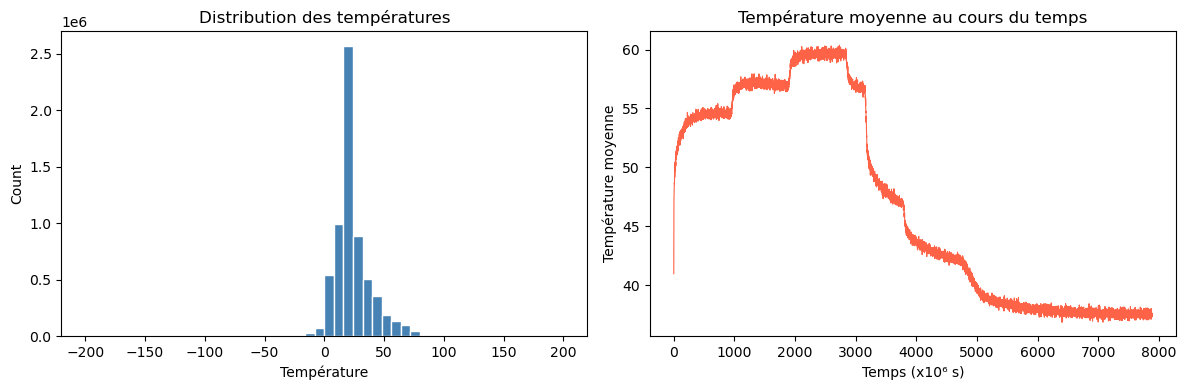

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['temperature'].dropna(), bins=50, color='steelblue', edgecolor='white', range=(-200, 200))
axes[0].set_title('Distribution des températures')
axes[0].set_xlabel('Température')
axes[0].set_ylabel('Count')

temp_by_time = train.groupby('time')['temperature'].mean()
axes[1].plot(temp_by_time.index / 1e6, temp_by_time.values, color='tomato', linewidth=0.8)
axes[1].set_title('Température moyenne au cours du temps')
axes[1].set_xlabel('Temps (x10⁶ s)')
axes[1].set_ylabel('Température moyenne')

plt.tight_layout()
plt.show()

In [5]:
import plotly.graph_objects as go

train_sensors = set(train['sensor'].unique())
test_sensors  = set(test['sensor'].unique())
s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

fig = go.Figure()
fig.add_trace(go.Scatter(x=s_train['coor_x'], y=s_train['coor_y'],
    mode='markers', name='Train sensors',
    marker=dict(size=6, color='steelblue', opacity=0.6)))
fig.add_trace(go.Scatter(x=s_test['coor_x'], y=s_test['coor_y'],
    mode='markers', name='Test sensors',
    marker=dict(size=8, color='tomato', symbol='diamond', opacity=0.9)))
fig.update_layout(title='Positions des capteurs (2D)', xaxis_title='X', yaxis_title='Y', width=700, height=500)
fig.show()

## 4. Preprocessing

### 4.1 Gestion des valeurs manquantes et aberrants

Le train set contient ~99k valeurs manquantes et ~108k températures aberrantes (hors [-10°C, 200°C]).
On les supprime **avant** le split train/val pour éviter de contaminer l'évaluation.

In [6]:
print(f'Lignes avant nettoyage : {len(train)}')
train_clean = train.dropna(subset=['temperature']).copy()
print(f'Après suppression NaN : {len(train_clean)}')

# Filtrage aberrants AVANT le split (évite de contaminer la validation)
mask_clean = (train_clean['temperature'] > -10) & (train_clean['temperature'] < 200)
train_clean = train_clean[mask_clean].copy()
print(f'Après filtrage aberrants : {len(train_clean)}')
print(f'Total supprimées : {len(train) - len(train_clean)} ({100*(len(train)-len(train_clean))/len(train):.1f}%)')

Lignes avant nettoyage : 6626928
Après suppression NaN : 6527525
Après filtrage aberrants : 6418812
Total supprimées : 208116 (3.1%)


### 4.2 Feature Engineering

Features motivées par la physique du transfert thermique :
- **dist_canister** : la température décroît avec la distance au canister
- **is_opa** : zone OPA pondérée plus fortement dans le score Kaggle  
- **time_log** : capture la dynamique exponentielle du transfert thermique
- **power_x_time** : interaction entre puissance et temps (montée en température)
- **dist_x_time** : interaction distance-temps (propagation du front thermique)

In [7]:
def add_features(df, sensors_df, t_max):
    """
    Joint les coordonnées spatiales et ajoute des features dérivées.

    Features :
    - coor_x, coor_y : position spatiale (coor_z = 0 partout -> ignoré)
    - dist_center : distance à l'origine
    - dist_canister : distance au centre du canister (x=0.7, y=1.2)
    - is_opa : 1 si zone OPA (x > 1.4m), 0 si buffer
    - time_norm : temps normalisé [0, 1]
    - time_log : log(1+t) pour capturer la dynamique exponentielle
    - power_x_time : interaction puissance × temps normalisé
    - dist_x_time : interaction distance × temps (propagation thermique)
    """
    merged = df.merge(sensors_df, on='sensor', how='left')

    # Features spatiales
    merged['dist_center']   = np.sqrt(merged['coor_x']**2 + merged['coor_y']**2)
    merged['dist_canister'] = np.sqrt((merged['coor_x'] - 0.7)**2 + (merged['coor_y'] - 1.2)**2)
    merged['is_opa']        = (merged['coor_x'] > 1.4).astype(float)

    # Features temporelles
    merged['time_norm']    = merged['time'] / t_max
    merged['time_log']     = np.log1p(merged['time'])

    # Features d'interaction (physique du transfert thermique)
    merged['power_x_time'] = merged['power'] * merged['time_norm']
    merged['dist_x_time']  = merged['dist_canister'] * merged['time_norm']

    return merged

t_max = train_clean['time'].max()
train_feat = add_features(train_clean, sensors, t_max)
test_feat  = add_features(test, sensors, t_max)

print('Features disponibles :', train_feat.columns.tolist())
display(train_feat.head(3))

Features disponibles : ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'dist_center', 'dist_canister', 'is_opa', 'time_norm', 'time_log', 'power_x_time', 'dist_x_time']


,sensor,time,power,temperature,coor_x,coor_y,coor_z,dist_center,dist_canister,is_opa,time_norm,time_log,power_x_time,dist_x_time
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000000,0.000000,0.000000,0.000000
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000110,13.669329,0.162991,0.004985
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000219,14.362476,0.325833,0.009970


In [8]:
TARGET = 'temperature'

FEATURES = ['coor_x', 'coor_y', 'time_norm', 'time_log', 'power',
            'dist_center', 'dist_canister', 'is_opa',
            'power_x_time', 'dist_x_time']

X = train_feat[FEATURES].values
y = train_feat[TARGET].values

print(f'X shape : {X.shape} — {len(FEATURES)} features')

X shape : (6418812, 10) — 10 features


### 4.3 Split train/validation & Normalisation

In [9]:
# Split 80/20 aléatoire
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation : fit sur train uniquement pour éviter le data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(test_feat[FEATURES].values)

assert len(X_test_s) == len(test)
print(f'Train : {X_train_s.shape} | Val : {X_val_s.shape} | Test : {X_test_s.shape}')

Train : (5135049, 10) | Val : (1283763, 10) | Test : (2190480, 10)


## 5. Modèle Baseline — Ridge Regression

Modèle linéaire rapide. Sert de référence minimale pour mesurer l'apport des modèles plus complexes.

In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

y_pred_val_ridge = ridge.predict(X_val_s)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_val_ridge))
print(f'Baseline Ridge — RMSE validation : {rmse_ridge:.4f}')

Baseline Ridge — RMSE validation : 9.2973


## 6. Modèle — k-Nearest Neighbors

kNN capture la continuité spatiale et temporelle : la température en un point inconnu
est approchée par celle de ses k voisins les plus proches dans l'espace des features.

In [11]:
sample_size = min(50000, len(X_train_s))
idx_knn = np.random.choice(len(X_train_s), sample_size, replace=False)

k_values = [3, 5, 10, 20]
rmse_k = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_s[idx_knn], y_train[idx_knn])
    pred = knn.predict(X_val_s[:5000])
    rmse = np.sqrt(mean_squared_error(y_val[:5000], pred))
    rmse_k.append(rmse)
    print(f'k={k:3d}  ->  RMSE = {rmse:.4f}')

best_k = k_values[np.argmin(rmse_k)]
print(f'\nMeilleur k : {best_k}')

k=  3  ->  RMSE = 5.0346
k=  5  ->  RMSE = 5.0123
k= 10  ->  RMSE = 5.1572
k= 20  ->  RMSE = 5.4945

Meilleur k : 5


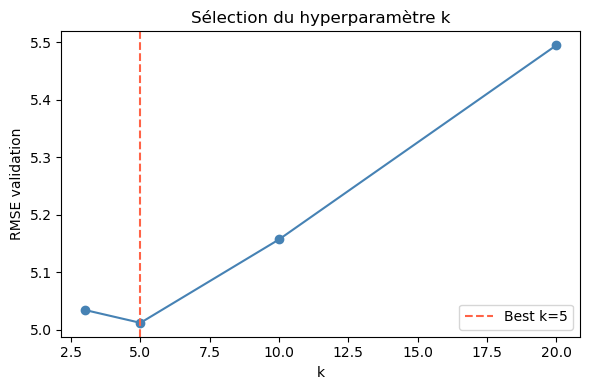

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, rmse_k, 'o-', color='steelblue')
plt.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('RMSE validation')
plt.title('Sélection du hyperparamètre k')
plt.legend(); plt.tight_layout(); plt.show()

In [13]:
knn_final = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_train_s, y_train)

y_pred_val_knn = knn_final.predict(X_val_s)
rmse_knn = np.sqrt(mean_squared_error(y_val, y_pred_val_knn))
print(f'kNN (k={best_k}) — RMSE validation : {rmse_knn:.4f}')

kNN (k=5) — RMSE validation : 4.2434


## 7. Modèle — Random Forest

Extension des Decision Trees (lab svm_trees). Entraîne 100 arbres indépendants en parallèle
et moyenne leurs prédictions — robuste aux outliers, capture les interactions non-linéaires.

In [14]:
np.random.seed(42)
idx_rf = np.random.choice(len(X_train_s), size=500_000, replace=False)

rf = RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
rf.fit(X_train_s[idx_rf], y_train[idx_rf])

y_pred_val_rf = rf.predict(X_val_s)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
print(f'Random Forest — RMSE validation : {rmse_rf:.4f}')

Random Forest — RMSE validation : 4.2675


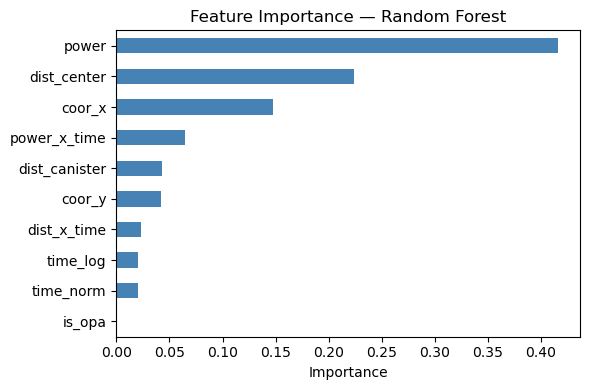

In [15]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(6, 4), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

## 8. Modèle — HistGradientBoosting

Variante optimisée du Gradient Boosting (lab svm_trees, section 3) qui supporte
les grands datasets sans sampling. Chaque arbre corrige les erreurs du précédent
via descente de gradient — lien direct avec SGD vu en cours.

Avantage clé : entraîné sur **toutes** les données (6M lignes) au lieu d'un sample.

In [16]:
# Entraînement sur tout le train set — pas de sampling nécessaire
hgb = HistGradientBoostingRegressor(
    max_iter=300,
    max_depth=10,
    learning_rate=0.1,
    min_samples_leaf=20,
    random_state=42
)
hgb.fit(X_train_s, y_train)

y_pred_val_hgb = hgb.predict(X_val_s)
rmse_hgb = np.sqrt(mean_squared_error(y_val, y_pred_val_hgb))
print(f'HistGradientBoosting — RMSE validation : {rmse_hgb:.4f}')

HistGradientBoosting — RMSE validation : 3.8824


## 9. Comparaison des modèles

,Modèle,RMSE Validation
0,HistGradientBoosting,3.882447
1,kNN (k=5),4.243422
2,Random Forest,4.267464
3,Ridge (baseline),9.297261


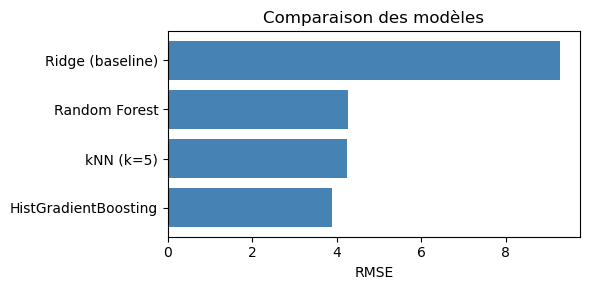

In [17]:
results = pd.DataFrame({
    'Modèle': ['Ridge (baseline)', f'kNN (k={best_k})', 'Random Forest', 'HistGradientBoosting'],
    'RMSE Validation': [rmse_ridge, rmse_knn, rmse_rf, rmse_hgb]
})
results = results.sort_values('RMSE Validation').reset_index(drop=True)
display(results)

plt.figure(figsize=(6, 3))
plt.barh(results['Modèle'], results['RMSE Validation'], color='steelblue')
plt.xlabel('RMSE')
plt.title('Comparaison des modèles')
plt.tight_layout()
plt.show()

## 10. Prédictions finales & Soumission

On sélectionne automatiquement le modèle avec le meilleur RMSE de validation.

In [19]:
best_rmse = min(rmse_ridge, rmse_knn, rmse_rf, rmse_hgb)

if best_rmse == rmse_hgb:
    y_pred = hgb.predict(X_test_s)
    best_model_name = 'HistGradientBoosting'
elif best_rmse == rmse_rf:
    y_pred = rf.predict(X_test_s)
    best_model_name = 'Random Forest'
elif best_rmse == rmse_knn:
    y_pred = knn_final.predict(X_test_s)
    best_model_name = f'kNN (k={best_k})'
else:
    y_pred = ridge.predict(X_test_s)
    best_model_name = 'Ridge'

print(f'Modèle sélectionné : {best_model_name} (RMSE = {best_rmse:.4f})')

submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'submission.csv sauvegardé — {len(submission)} lignes')
display(submission.head())

Modèle sélectionné : HistGradientBoosting (RMSE = 3.8824)
submission.csv sauvegardé — 2190480 lignes


,Id,temperature
0,0,16.377492
1,1,16.377492
2,2,16.421526
3,3,16.421526
4,4,16.421526


## 11. Pistes d'amélioration

- **Deep Learning (PyTorch)** : réseau de neurones avec GPU pour capturer des patterns complexes
- **Features physiques** : coordonnées polaires, gradient de température estimé, distance à la surface
- **Blending** : moyenne pondérée RF + HGB pour réduire la variance des prédictions
- **Split par capteur** : validation plus honnête pour mieux estimer le score Kaggle réel